In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("hotel_bookings.csv")

In [3]:
len(df.columns)

32

In [4]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

In [5]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
119385    False
119386    False
119387    False
119388    False
119389    False
Length: 119390, dtype: bool

In [6]:
# Display column names
df.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date']

In [7]:
# Count missing values
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

company     112593
agent        16340
country        488
children         4
dtype: int64

In [8]:
df['company']

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
          ..
119385   NaN
119386   NaN
119387   NaN
119388   NaN
119389   NaN
Name: company, Length: 119390, dtype: float64

In [9]:
# Count duplicate rows
df.duplicated().sum()

np.int64(31994)

In [10]:
df['is_canceled']

0         0
1         0
2         0
3         0
4         0
         ..
119385    0
119386    0
119387    0
119388    0
119389    0
Name: is_canceled, Length: 119390, dtype: int64

In [11]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (87396, 32)


In [12]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(15))


--- hotel ---
hotel
City Hotel      53428
Resort Hotel    33968
Name: count, dtype: int64

--- arrival_date_month ---
arrival_date_month
August       11257
July         10057
May           8355
April         7908
June          7765
March         7513
October       6934
September     6690
February      6098
December      5131
November      4995
January       4693
Name: count, dtype: int64

--- meal ---
meal
BB           67978
SC            9481
HB            9085
Undefined      492
FB             360
Name: count, dtype: int64

--- country ---
country
PRT    27453
GBR    10433
FRA     8837
ESP     7252
DEU     5387
ITA     3066
IRL     3016
BEL     2081
BRA     1995
NLD     1911
USA     1875
CHE     1570
CN      1093
AUT      947
SWE      837
Name: count, dtype: int64

--- market_segment ---
market_segment
Online TA        51618
Offline TA/TO    13889
Direct           11804
Groups            4942
Corporate         4212
Complementary      702
Aviation           227
Undefined            2

C:\Users\Administrator\AppData\Local\Temp\ipykernel_18628\1383880554.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [13]:
target = "is_canceled"

In [14]:
df[["is_canceled", "reservation_status", "reservation_status_date"]].head(10)

,is_canceled,reservation_status,reservation_status_date
0,0,Check-Out,2015-07-01
1,0,Check-Out,2015-07-01
2,0,Check-Out,2015-07-02
3,0,Check-Out,2015-07-02
4,0,Check-Out,2015-07-03
6,0,Check-Out,2015-07-03
7,0,Check-Out,2015-07-03
8,1,Canceled,2015-05-06
9,1,Canceled,2015-04-22
10,1,Canceled,2015-06-23


In [15]:
#lekage colums sepration 
leakage_columns = [
    "reservation_status",
    "reservation_status_date"
]


In [16]:
df = df.drop(columns=leakage_columns)

print("Removed leakage columns:", leakage_columns)

Removed leakage columns: ['reservation_status', 'reservation_status_date']


In [17]:
df.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

In [18]:
df['is_canceled']

0         0
1         0
2         0
3         0
4         0
         ..
119385    0
119386    0
119387    0
119388    0
119389    0
Name: is_canceled, Length: 87396, dtype: int64

In [19]:
X = df.drop(columns="is_canceled")
y = df["is_canceled"]

In [20]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (87396, 29)
Target: (87396,)


In [21]:
y.value_counts()

is_canceled
0    63371
1    24025
Name: count, dtype: int64

In [22]:
y.value_counts(normalize=True) * 100

is_canceled
0    72.510184
1    27.489816
Name: proportion, dtype: float64

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean plotting style
sns.set_theme(style="whitegrid")

In [24]:
cancellation_rate = df["is_canceled"].mean() * 100

print(f"Overall cancellation rate: {cancellation_rate:.2f}%")

Overall cancellation rate: 27.49%


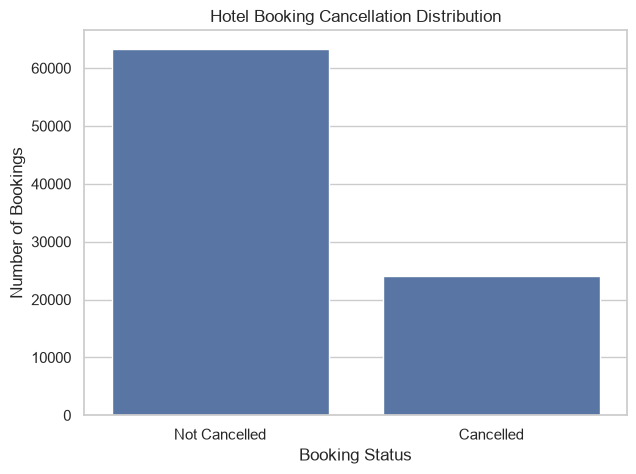

In [25]:
cancellation_counts = df["is_canceled"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=["Not Cancelled", "Cancelled"],
    y=[
        cancellation_counts[0],
        cancellation_counts[1]
    ]
)

plt.title("Hotel Booking Cancellation Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")

plt.show()

In [26]:
hotel_cancellation = (
    df.groupby("hotel")["is_canceled"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print(hotel_cancellation)

hotel
City Hotel      30.038557
Resort Hotel    23.480923
Name: is_canceled, dtype: float64


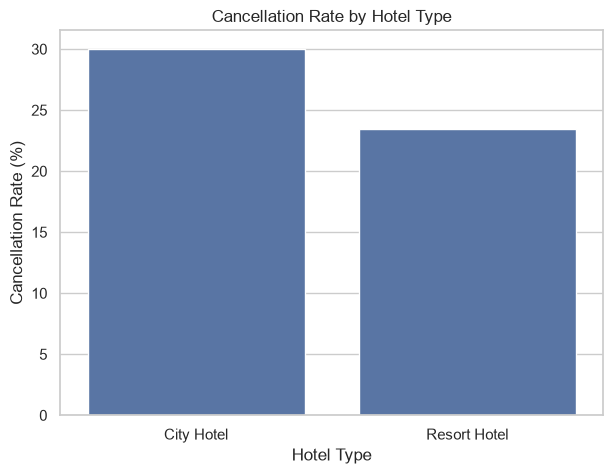

In [27]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=hotel_cancellation.index,
    y=hotel_cancellation.values
)

plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")

plt.show()

In [28]:
df["lead_time_group"] = pd.cut(
    df["lead_time"],
    bins=[-1, 7, 30, 90, 180, 365, float("inf")],
    labels=[
        "0-7 days",
        "8-30 days",
        "31-90 days",
        "91-180 days",
        "181-365 days",
        "365+ days"
    ]
)

In [29]:
lead_time_cancellation = (
    df.groupby("lead_time_group", observed=True)["is_canceled"]
      .mean()
      .mul(100)
)

print(lead_time_cancellation)

lead_time_group
0-7 days         8.429851
8-30 days       25.367197
31-90 days      32.008442
91-180 days     34.983281
181-365 days    39.678571
365+ days       40.884956
Name: is_canceled, dtype: float64


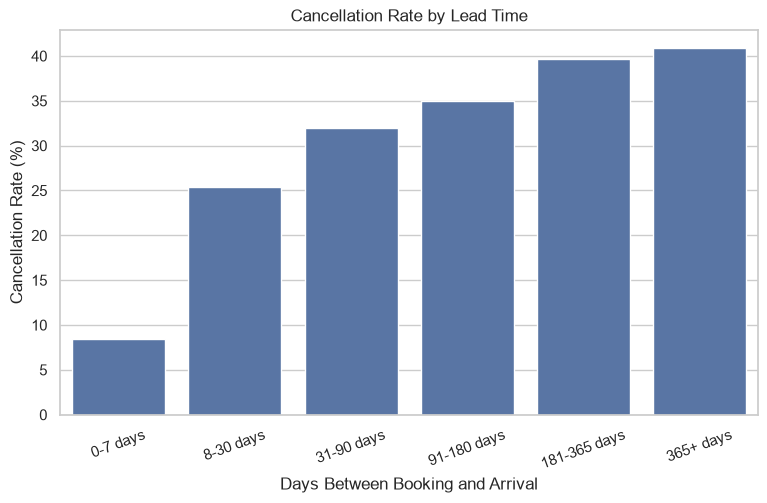

In [30]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=lead_time_cancellation.index,
    y=lead_time_cancellation.values
)

plt.title("Cancellation Rate by Lead Time")
plt.xlabel("Days Between Booking and Arrival")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=20)

plt.show()

In [31]:
deposit_cancellation = (
    df.groupby("deposit_type")["is_canceled"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print(deposit_cancellation)

deposit_type
Non Refund    94.701349
No Deposit    26.684908
Refundable    24.299065
Name: is_canceled, dtype: float64


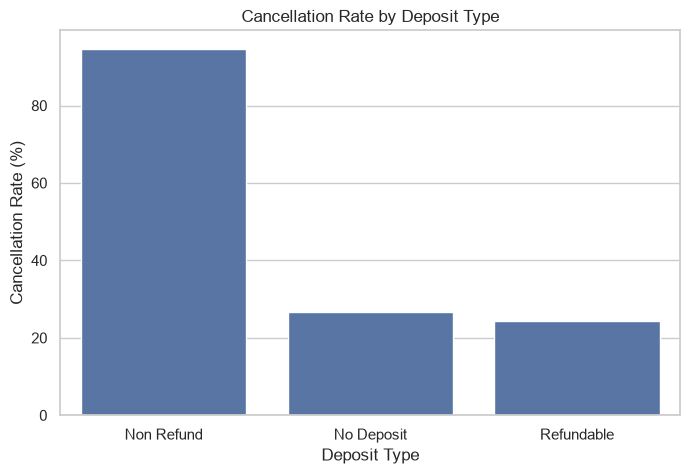

In [32]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=deposit_cancellation.index,
    y=deposit_cancellation.values
)

plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate (%)")

plt.show()

Market Segment

Now we'll investigate where bookings are coming from.

In [33]:
market_cancellation = (
    df.groupby("market_segment")["is_canceled"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print(market_cancellation)

market_segment
Undefined        100.000000
Online TA         35.346197
Groups            27.013355
Aviation          19.823789
Offline TA/TO     14.853481
Direct            14.715351
Complementary     12.535613
Corporate         12.108262
Name: is_canceled, dtype: float64


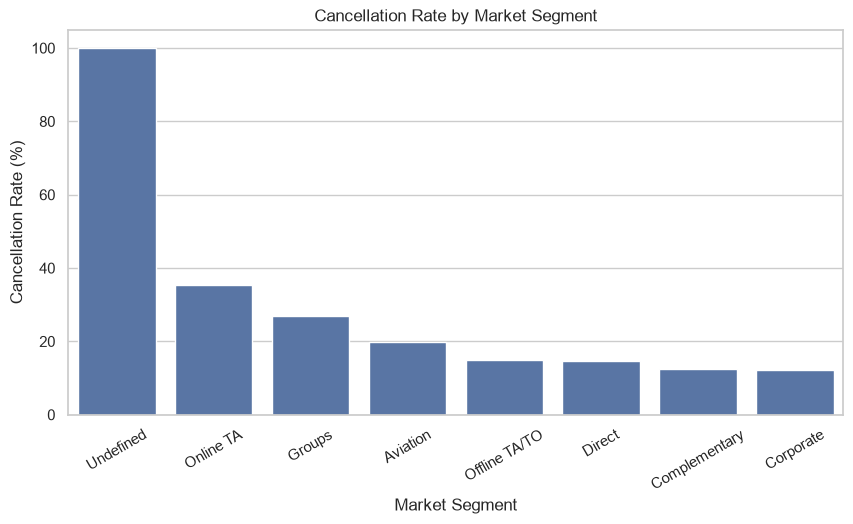

In [34]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=market_cancellation.index,
    y=market_cancellation.values
)

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=30)

plt.show()

Previous Cancellations

This is especially useful because it answers:

Do customers who cancelled before tend to cancel again?

In [35]:
df["has_previous_cancellation"] = (
    df["previous_cancellations"] > 0
).map({
    False: "No Previous Cancellation",
    True: "Previous Cancellation"
})

In [36]:
previous_cancel_rate = (
    df.groupby("has_previous_cancellation")["is_canceled"]
      .mean()
      .mul(100)
)

print(previous_cancel_rate)

has_previous_cancellation
No Previous Cancellation    26.695523
Previous Cancellation       67.893175
Name: is_canceled, dtype: float64


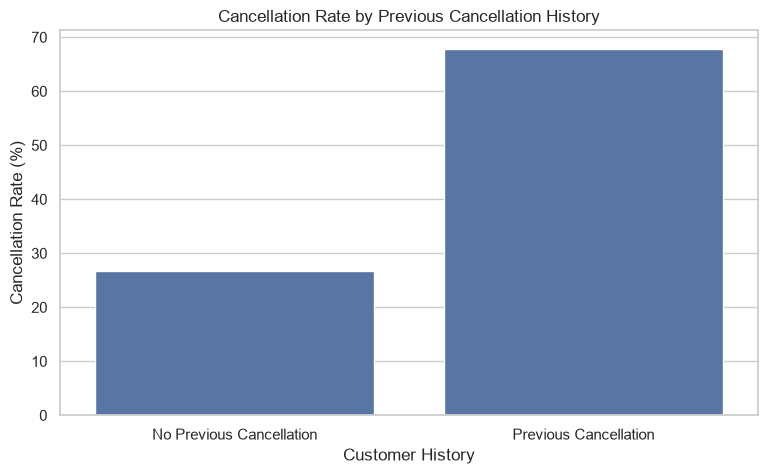

In [37]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=previous_cancel_rate.index,
    y=previous_cancel_rate.values
)

plt.title("Cancellation Rate by Previous Cancellation History")
plt.xlabel("Customer History")
plt.ylabel("Cancellation Rate (%)")

plt.show()

In [38]:
print(hotel_cancellation)
print(lead_time_cancellation)
print(deposit_cancellation)
print(market_cancellation)
print(previous_cancel_rate)

hotel
City Hotel      30.038557
Resort Hotel    23.480923
Name: is_canceled, dtype: float64
lead_time_group
0-7 days         8.429851
8-30 days       25.367197
31-90 days      32.008442
91-180 days     34.983281
181-365 days    39.678571
365+ days       40.884956
Name: is_canceled, dtype: float64
deposit_type
Non Refund    94.701349
No Deposit    26.684908
Refundable    24.299065
Name: is_canceled, dtype: float64
market_segment
Undefined        100.000000
Online TA         35.346197
Groups            27.013355
Aviation          19.823789
Offline TA/TO     14.853481
Direct            14.715351
Complementary     12.535613
Corporate         12.108262
Name: is_canceled, dtype: float64
has_previous_cancellation
No Previous Cancellation    26.695523
Previous Cancellation       67.893175
Name: is_canceled, dtype: float64


In [39]:
print("Deposit type counts:")
print(df["deposit_type"].value_counts())

print("\nMarket segment counts:")
print(df["market_segment"].value_counts())

Deposit type counts:
deposit_type
No Deposit    86251
Non Refund     1038
Refundable      107
Name: count, dtype: int64

Market segment counts:
market_segment
Online TA        51618
Offline TA/TO    13889
Direct           11804
Groups            4942
Corporate         4212
Complementary      702
Aviation           227
Undefined            2
Name: count, dtype: int64


In [40]:
df["total_stay_duration"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

df[[
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "total_stay_duration"
]].head()

,stays_in_weekend_nights,stays_in_week_nights,total_stay_duration
0,0,0,0
1,0,0,0
2,0,1,1
3,0,1,1
4,0,2,2


In [41]:
df["total_guests"] = (
    df["adults"] +
    df["children"].fillna(0) +
    df["babies"]
)

df[[
    "adults",
    "children",
    "babies",
    "total_guests"
]].head()

,adults,children,babies,total_guests
0,2,0.0,0,2.0
1,2,0.0,0,2.0
2,1,0.0,0,1.0
3,1,0.0,0,1.0
4,2,0.0,0,2.0


In [42]:
df["total_children_babies"] = (
    df["children"].fillna(0) +
    df["babies"]
)

df[[
    "children",
    "babies",
    "total_children_babies"
]].head()

,children,babies,total_children_babies
0,0.0,0,0.0
1,0.0,0,0.0
2,0.0,0,0.0
3,0.0,0,0.0
4,0.0,0,0.0


In [43]:

df["booking_to_arrival"] = df["lead_time"]

df[[
    "lead_time",
    "booking_to_arrival"
]].head()

,lead_time,booking_to_arrival
0,342,342
1,737,737
2,7,7
3,13,13
4,14,14


In [44]:
df["has_previous_cancellation"] = (
    df["previous_cancellations"] > 0
).astype(int)

df[[
    "previous_cancellations",
    "has_previous_cancellation"
]].head()

,previous_cancellations,has_previous_cancellation
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


In [45]:
df["has_special_requests"] = (
    df["total_of_special_requests"] > 0
).astype(int)

df[[
    "total_of_special_requests",
    "has_special_requests"
]].head()

,total_of_special_requests,has_special_requests
0,0,0
1,0,0
2,0,0
3,0,0
4,1,1


In [46]:

df["arrival_month"] = df["arrival_date_month"]

In [47]:
df["arrival_day"] = df["arrival_date_day_of_month"]

In [48]:
df["arrival_week"] = df["arrival_date_week_number"]

In [49]:
df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-" +
    df["arrival_date_month"] + "-" +
    df["arrival_date_day_of_month"].astype(str)
)

df["arrival_date"].head()

0   2015-07-01
1   2015-07-01
2   2015-07-01
3   2015-07-01
4   2015-07-01
Name: arrival_date, dtype: datetime64[us]

In [50]:
df["arrival_month_num"] = df["arrival_date"].dt.month
df["arrival_day_of_week"] = df["arrival_date"].dt.dayofweek

In [51]:
df["total_previous_bookings"] = (
    df["previous_cancellations"] +
    df["previous_bookings_not_canceled"]
)

In [52]:
engineered_features = [
    "total_stay_duration",
    "total_guests",
    "total_children_babies",
    "booking_to_arrival",
    "has_previous_cancellation",
    "has_special_requests",
    "arrival_month_num",
    "arrival_day_of_week",
    "total_previous_bookings"
]

df[engineered_features].head()

,total_stay_duration,total_guests,total_children_babies,booking_to_arrival,has_previous_cancellation,has_special_requests,arrival_month_num,arrival_day_of_week,total_previous_bookings
0,0,2.0,0.0,342,0,0,7,2,0
1,0,2.0,0.0,737,0,0,7,2,0
2,1,1.0,0.0,7,0,0,7,2,0
3,1,1.0,0.0,13,0,0,7,2,0
4,2,2.0,0.0,14,0,1,7,2,0


In [53]:
df[
    (df["adults"] == 0) &
    (df["children"].fillna(0) == 0) &
    (df["babies"] == 0)
].shape

(166, 44)

In [54]:
df[engineered_features].describe()

,total_stay_duration,total_guests,total_children_babies,booking_to_arrival,has_previous_cancellation,has_special_requests,arrival_month_num,arrival_day_of_week,total_previous_bookings
count,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000
mean,3.630658,2.025253,0.149458,79.891368,0.019280,0.497757,6.475663,2.979839,0.214403
std,2.763449,0.794319,0.471728,86.052325,0.137508,0.499998,3.097576,2.006724,1.907101
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,2.000000,2.000000,0.000000,11.000000,0.000000,0.000000,4.000000,1.000000,0.000000
50%,3.000000,2.000000,0.000000,49.000000,0.000000,0.000000,7.000000,3.000000,0.000000
75%,5.000000,2.000000,0.000000,125.000000,0.000000,1.000000,9.000000,5.000000,0.000000
max,69.000000,55.000000,10.000000,737.000000,1.000000,1.000000,12.000000,6.000000,78.000000


Build & Compare 3 Models

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [56]:
features = [
    # Booking information
    "lead_time",
    "hotel",
    "meal",
    "market_segment",
    "distribution_channel",
    
    # Guest information
    "adults",
    "children",
    "babies",
    
    # Stay information
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "total_stay_duration",
    "total_guests",
    "total_children_babies",
    
    # Customer history
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "total_previous_bookings",
    "has_previous_cancellation",
    
    # Booking changes / requests
    "booking_changes",
    "total_of_special_requests",
    "has_special_requests",
    
    # Room information
    "reserved_room_type",
    "assigned_room_type",
    
    # Payment / customer type
    "deposit_type",
    "customer_type",
    
    # Pricing
    "adr",
    
    # Arrival information
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "arrival_month_num",
    "arrival_day_of_week"
]

In [57]:
X = df[features]
y = df["is_canceled"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (87396, 32)
y shape: (87396,)


In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 69916
Testing rows: 17480


In [59]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['hotel', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'arrival_date_month']

Numerical features:
['lead_time', 'adults', 'children', 'babies', 'stays_in_weekend_nights', 'stays_in_week_nights', 'total_stay_duration', 'total_guests', 'total_children_babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'total_previous_bookings', 'has_previous_cancellation', 'booking_changes', 'total_of_special_requests', 'has_special_requests', 'adr', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month']


C:\Users\Administrator\AppData\Local\Temp\ipykernel_18628\2339720342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [62]:
from sklearn.impute import SimpleImputer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numerical_features
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

In [63]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](32,)","['lead_time','hotel','meal',...,'arrival_date_day_of_month', 'arrival_month_num','arrival_day_of_week']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,32
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [64]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](32,)","['lead_time','hotel','meal',...,'arrival_date_day_of_month', 'arrival_month_num','arrival_day_of_week']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,32
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [65]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1
            )
        )
    ]
)

xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](32,)","['lead_time','hotel','meal',...,'arrival_date_day_of_month', 'arrival_month_num','arrival_day_of_week']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,32
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [71]:
logistic_predictions = logistic_model.predict(X_test)
rf_predictions = random_forest_model.predict(X_test)
xgb_predictions = xgb_model.predict(X_test)

In [67]:
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]
rf_probabilities = random_forest_model.predict_proba(X_test)[:, 1]
xgb_probabilities = xgb_model.predict_proba(X_test)[:, 1]

Model Evaluation

In [68]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [73]:
def evaluate_model(name, y_true, predictions, probabilities):
    
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions),
        "Recall": recall_score(y_true, predictions),
        "F1-Score": f1_score(y_true, predictions),
        "ROC-AUC": roc_auc_score(y_true, probabilities)
    }

In [72]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_predictions,
        logistic_probabilities
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions,
        rf_probabilities
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_predictions,
        xgb_probabilities
    )
)

In [74]:
results_df = pd.DataFrame(results)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7887,0.6970,0.4094,0.5158,0.7905
1,Random Forest,0.8105,0.7111,0.5234,0.6030,0.8373
2,XGBoost,0.8119,0.7306,0.5001,0.5938,0.8465


In [75]:
print("LOGISTIC REGRESSION")
print(classification_report(y_test, logistic_predictions))

print("\nRANDOM FOREST")
print(classification_report(y_test, rf_predictions))

print("\nXGBOOST")
print(classification_report(y_test, xgb_predictions))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.81      0.93      0.86     12675
           1       0.70      0.41      0.52      4805

    accuracy                           0.79     17480
   macro avg       0.75      0.67      0.69     17480
weighted avg       0.78      0.79      0.77     17480


RANDOM FOREST
              precision    recall  f1-score   support

           0       0.84      0.92      0.88     12675
           1       0.71      0.52      0.60      4805

    accuracy                           0.81     17480
   macro avg       0.77      0.72      0.74     17480
weighted avg       0.80      0.81      0.80     17480


XGBOOST
              precision    recall  f1-score   support

           0       0.83      0.93      0.88     12675
           1       0.73      0.50      0.59      4805

    accuracy                           0.81     17480
   macro avg       0.78      0.72      0.74     17480
weighted avg       0.80      0

In [76]:
cm_logistic = confusion_matrix(
    y_test,
    logistic_predictions
)

print(cm_logistic)

[[11820   855]
 [ 2838  1967]]


In [77]:
cm_rf = confusion_matrix(
    y_test,
    rf_predictions
)

print(cm_rf)

[[11653  1022]
 [ 2290  2515]]


In [78]:

cm_xgb = confusion_matrix(
    y_test,
    xgb_predictions
)

print(cm_xgb)

[[11789   886]
 [ 2402  2403]]


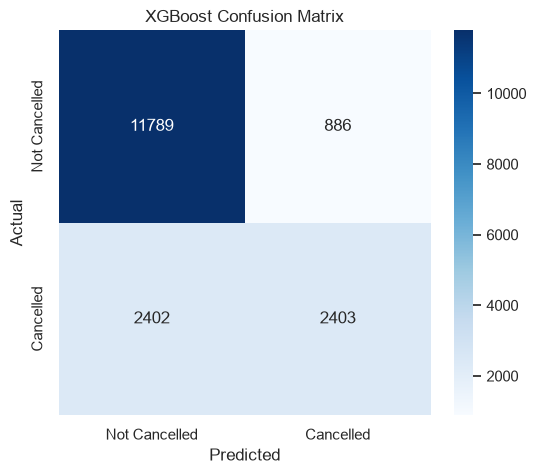

In [79]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Cancelled", "Cancelled"],
    yticklabels=["Not Cancelled", "Cancelled"]
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [80]:
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7887,0.6970,0.4094,0.5158,0.7905
1,Random Forest,0.8105,0.7111,0.5234,0.6030,0.8373
2,XGBoost,0.8119,0.7306,0.5001,0.5938,0.8465


Interpretability

In [81]:
# Get the trained XGBoost model from the pipeline
xgb_classifier = xgb_model.named_steps["model"]

# Get the preprocessor
xgb_preprocessor = xgb_model.named_steps["preprocessor"]

# Get feature names after preprocessing
feature_names = xgb_preprocessor.get_feature_names_out()

# Get XGBoost feature importance
importance = xgb_classifier.feature_importances_

# Create feature importance DataFrame
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})

# Sort by importance
feature_importance_df = (
    feature_importance_df
    .sort_values("importance", ascending=False)
)

feature_importance_df.head(10)

,feature,importance
63,cat__deposit_type_Non Refund,0.162278
16,num__has_special_requests,0.050358
33,cat__market_segment_Offline TA/TO,0.049133
62,cat__deposit_type_No Deposit,0.045560
34,cat__market_segment_Online TA,0.045049
13,num__has_previous_cancellation,0.037110
39,cat__distribution_channel_TA/TO,0.036579
10,num__previous_cancellations,0.036031
15,num__total_of_special_requests,0.034983
67,cat__customer_type_Transient,0.032617


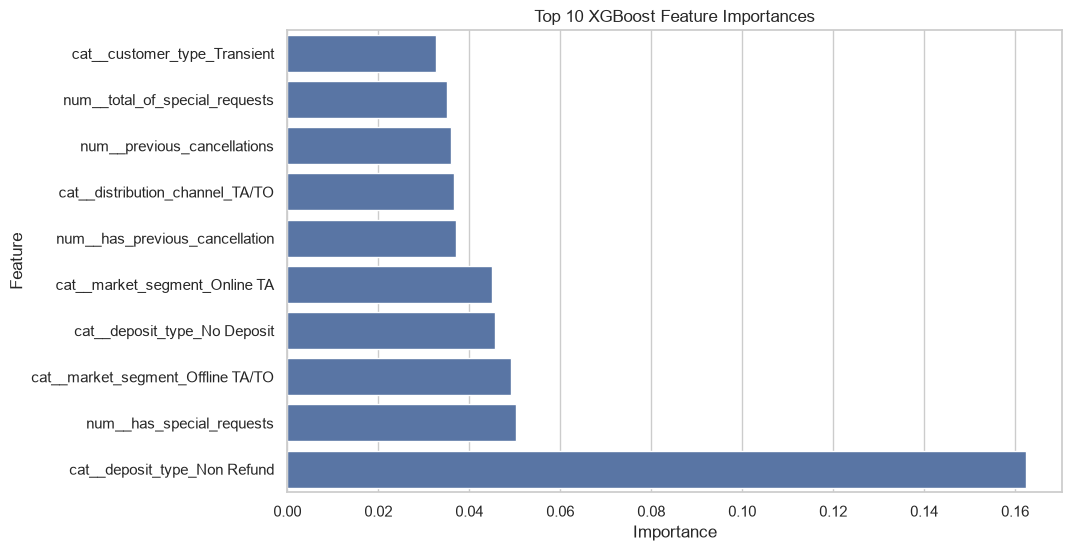

In [ ]:
top_features = feature_importance_df.head(10).sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top 10 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [83]:
import joblib

# Save the complete XGBoost pipeline
joblib.dump(xgb_model, "hotel_cancellation_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [84]:
loaded_model = joblib.load("hotel_cancellation_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


Create a new booking

In [85]:
new_booking = pd.DataFrame([{
    "lead_time": 200,
    "hotel": "City Hotel",
    "meal": "BB",
    "market_segment": "Online TA",
    "distribution_channel": "TA/TO",
    
    "adults": 2,
    "children": 0,
    "babies": 0,
    
    "stays_in_weekend_nights": 2,
    "stays_in_week_nights": 5,
    "total_stay_duration": 7,
    "total_guests": 2,
    "total_children_babies": 0,
    
    "is_repeated_guest": 0,
    "previous_cancellations": 0,
    "previous_bookings_not_canceled": 0,
    "total_previous_bookings": 0,
    "has_previous_cancellation": 0,
    
    "booking_changes": 0,
    "total_of_special_requests": 1,
    "has_special_requests": 1,
    
    "reserved_room_type": "A",
    "assigned_room_type": "A",
    
    "deposit_type": "No Deposit",
    "customer_type": "Transient",
    
    "adr": 100,
    
    "arrival_date_year": 2017,
    "arrival_date_month": "July",
    "arrival_date_week_number": 27,
    "arrival_date_day_of_month": 5,
    "arrival_month_num": 7,
    "arrival_day_of_week": 2
}])

In [86]:
cancellation_probability = loaded_model.predict_proba(
    new_booking
)[0][1]

prediction = loaded_model.predict(new_booking)[0]

print(f"Cancellation Probability: {cancellation_probability:.2%}")
print(f"Prediction: {'Cancelled' if prediction == 1 else 'Not Cancelled'}")

Cancellation Probability: 35.94%
Prediction: Not Cancelled


In [87]:
if cancellation_probability >= 0.70:
    risk_level = "HIGH"
elif cancellation_probability >= 0.40:
    risk_level = "MEDIUM"
else:
    risk_level = "LOW"

print(f"Cancellation Probability: {cancellation_probability:.2%}")
print(f"Prediction: {'Cancelled' if prediction == 1 else 'Not Cancelled'}")
print(f"Risk Level: {risk_level}")

Cancellation Probability: 35.94%
Prediction: Not Cancelled
Risk Level: LOW
